In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv('../../raw dataset/diabetes_binary_health_indicators_BRFSS2015.csv')

# Pisahkan fitur (X) dan target (y)
X = df.drop('Diabetes_binary', axis=1)  
y = df['Diabetes_binary']              

print(f"Fitur: {X.columns.tolist()}")
print(f"Jumlah fitur: {X.shape[1]}")   
print(f"Jumlah sampel: {X.shape[0]}")   

Fitur: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
Jumlah fitur: 21
Jumlah sampel: 253680


In [12]:
# Split train/test
# Split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train: {X_train.shape[0]:,} samples')
print(f'Test: {X_test.shape[0]:,} samples')
print(f'\nTrain class distribution:')
print(y_train.value_counts(normalize=True).round(3))

Train: 202,944 samples
Test: 50,736 samples

Train class distribution:
Diabetes_binary
0.0    0.861
1.0    0.139
Name: proportion, dtype: float64


In [13]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
# Baseline: Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, 
    roc_auc_score, 
    confusion_matrix,
    RocCurveDisplay
)

lr = LogisticRegression(
    max_iter=1000,          
    class_weight='balanced', 
    random_state=42
)
lr.fit(X_train_scaled, y_train)

# Prediksi
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]  # probabilitas kelas 1

# Evaluasi
print("LOGISTIC REGRESSION — Evaluation")
print(classification_report(y_test, y_pred_lr, target_names=['Non-Diabetes', 'Diabetes/Pre']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_lr):.4f}")

LOGISTIC REGRESSION — Evaluation
              precision    recall  f1-score   support

Non-Diabetes       0.95      0.73      0.82     43667
Diabetes/Pre       0.31      0.76      0.44      7069

    accuracy                           0.73     50736
   macro avg       0.63      0.74      0.63     50736
weighted avg       0.86      0.73      0.77     50736

AUC-ROC: 0.8196


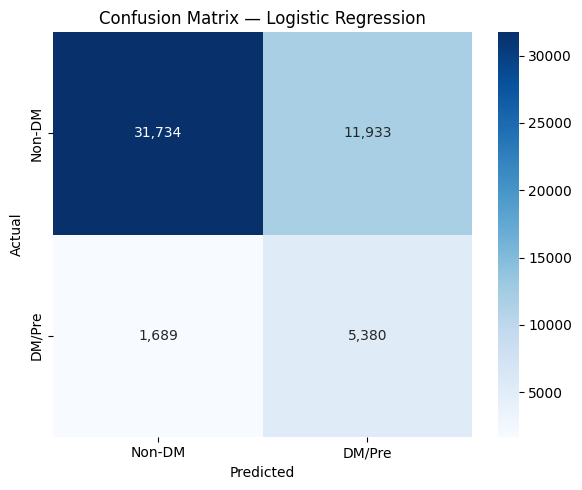

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
            xticklabels=['Non-DM', 'DM/Pre'],
            yticklabels=['Non-DM', 'DM/Pre'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

In [16]:
# Model Lanjutan: XGBoost
from xgboost import XGBClassifier

ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {ratio:.2f}")

xgb = XGBClassifier(
    n_estimators=200,        
    max_depth=6,              
    learning_rate=0.1,       
    scale_pos_weight=ratio,   
    eval_metric='aucpr',      
    random_state=42,
    n_jobs=-1              
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("XGBOOST — Evaluation")
print(classification_report(y_test, y_pred_xgb, target_names=['Non-Diabetes', 'Diabetes/Pre']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

scale_pos_weight: 6.18
XGBOOST — Evaluation
              precision    recall  f1-score   support

Non-Diabetes       0.95      0.72      0.82     43667
Diabetes/Pre       0.31      0.78      0.44      7069

    accuracy                           0.73     50736
   macro avg       0.63      0.75      0.63     50736
weighted avg       0.86      0.73      0.77     50736

AUC-ROC: 0.8250


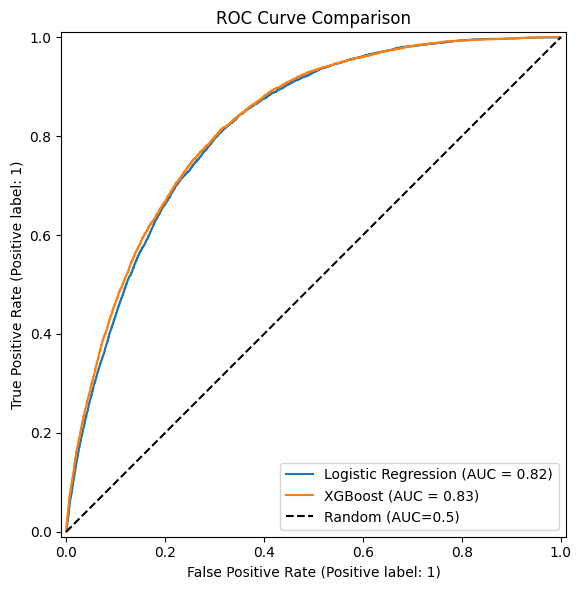

In [17]:
# Bandingkan Dua Model
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_proba_lr, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_xgb, name="XGBoost", ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.show()

d:\Applications\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


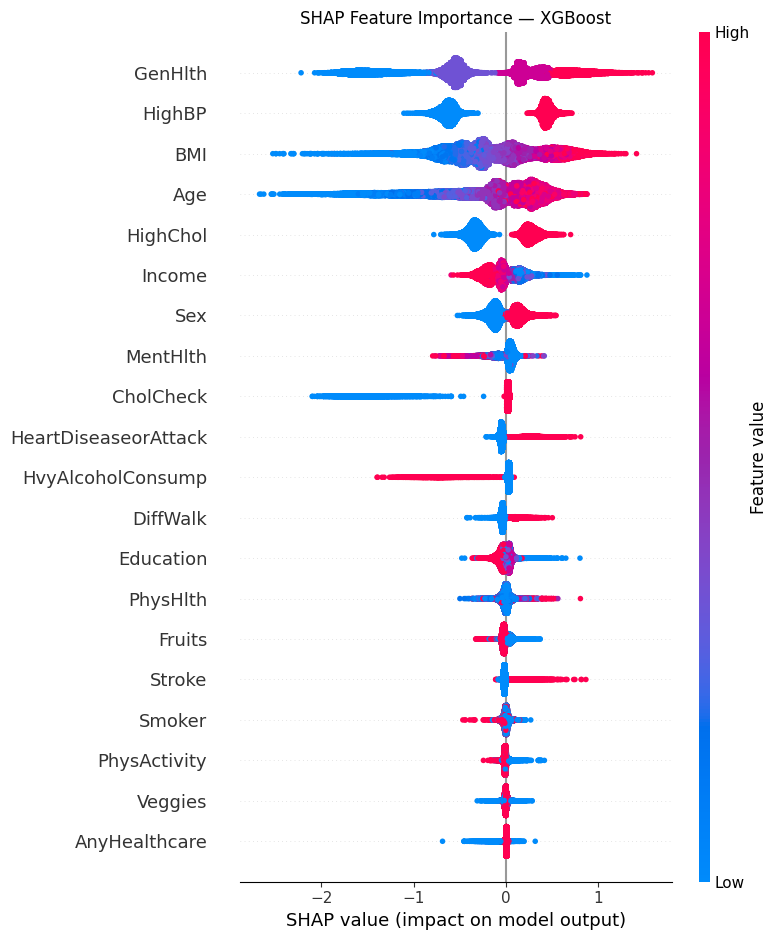

In [18]:
# SHAP Feature Importance
import shap

# Buat SHAP explainer untuk model terbaik (XGBoost)
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Feature Importance — XGBoost')
plt.tight_layout()
plt.show()

In [19]:
import joblib
import json
import os

output_dir = '../assessment/ml'
os.makedirs(output_dir, exist_ok=True)

best_model = xgb 
joblib.dump(best_model, f'{output_dir}/model.joblib')
print(f"Model saved to {output_dir}/model.joblib")

joblib.dump(scaler, f'{output_dir}/scaler.joblib')
print(f"Scaler saved to {output_dir}/scaler.joblib")

metadata = {
    'feature_names': X.columns.tolist(),
    'model_type': 'XGBClassifier',
    'auc_roc': float(roc_auc_score(y_test, y_proba_xgb)),
    'risk_thresholds': {'low_max': 0.3, 'moderate_max': 0.6},
    'needs_scaling': False,
    'training_date': pd.Timestamp.now().isoformat(),
    'dataset': 'BRFSS 2015 Diabetes Health Indicators',
    'n_training_samples': len(X_train),
}

with open(f'{output_dir}/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"Metadata saved to {output_dir}/model_metadata.json")

print(f"\nFeature order (HARUS SAMA saat prediksi dari form):")
for i, col in enumerate(X.columns):
    print(f"{i}: {col}")

Model saved to ../assessment/ml/model.joblib
Scaler saved to ../assessment/ml/scaler.joblib
Metadata saved to ../assessment/ml/model_metadata.json

Feature order (HARUS SAMA saat prediksi dari form):
0: HighBP
1: HighChol
2: CholCheck
3: BMI
4: Smoker
5: Stroke
6: HeartDiseaseorAttack
7: PhysActivity
8: Fruits
9: Veggies
10: HvyAlcoholConsump
11: AnyHealthcare
12: NoDocbcCost
13: GenHlth
14: MentHlth
15: PhysHlth
16: DiffWalk
17: Sex
18: Age
19: Education
20: Income
